# Clase 14 — Proyecto de clasificación

Cerramos el módulo con un proyecto que junta todo lo que venimos armando: un dataset propio con pandas (Clases 9-11), un modelo entrenado con scikit-learn (Clases 12 y 13) y ahora un gráfico nuevo, muy visual: la **frontera de decisión**, que muestra cómo "piensa" el modelo en todo el plano, no solo en los puntos que le dimos.

Tema de hoy: clasificar personajes de un videojuego inventado en `guerrero` o `mago`, según su `fuerza` y `velocidad`.

**Objetivos de la clase:**
- Armar un dataset de personajes con pandas.
- Entrenar un modelo con `Pipeline` (repaso de Clase 13).
- Ver la matriz de confusión como gráfico (repaso de Clase 12).
- Dibujar la frontera de decisión del modelo sobre todo el plano.
- Crear tu propio personaje y ver a qué clase pertenece, visualmente.


---
## 1. Armar el dataset de personajes

`fuerza` y `velocidad`, ambas de 0 a 100. Los guerreros tienden a mucha fuerza y poca velocidad; los magos, al revés.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(3)
n_por_clase = 35

guerreros = pd.DataFrame({
    "fuerza": np.random.normal(loc=70, scale=12, size=n_por_clase),
    "velocidad": np.random.normal(loc=35, scale=12, size=n_por_clase),
    "clase": "guerrero",
})

magos = pd.DataFrame({
    "fuerza": np.random.normal(loc=35, scale=12, size=n_por_clase),
    "velocidad": np.random.normal(loc=70, scale=12, size=n_por_clase),
    "clase": "mago",
})

personajes = pd.concat([guerreros, magos], ignore_index=True)
personajes[["fuerza", "velocidad"]] = personajes[["fuerza", "velocidad"]].clip(lower=1, upper=100)

print("Forma del dataset:", personajes.shape)
personajes.sample(5, random_state=1)


Forma del dataset: (70, 3)


,fuerza,velocidad,clase
65,45.491429,64.259624,mago
26,77.502940,51.004854,guerrero
66,19.477560,64.512871,mago
54,23.337914,72.709003,mago
27,68.073840,32.631024,guerrero


---
## 2. Visualizar antes de entrenar


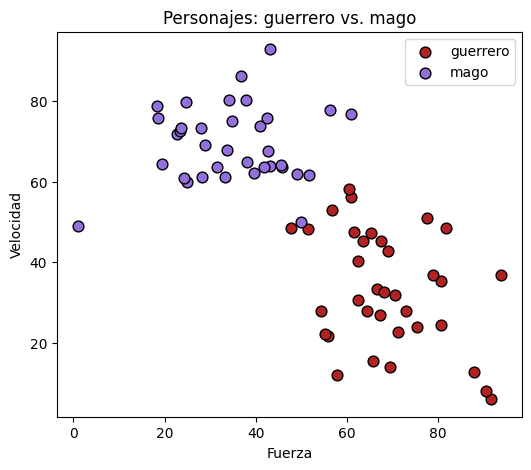

In [2]:
colores = {"guerrero": "firebrick", "mago": "mediumpurple"}

fig, ax = plt.subplots(figsize=(6, 5))
for clase, grupo in personajes.groupby("clase"):
    ax.scatter(grupo["fuerza"], grupo["velocidad"], label=clase, color=colores[clase], edgecolor="black", s=60)

ax.set_xlabel("Fuerza")
ax.set_ylabel("Velocidad")
ax.set_title("Personajes: guerrero vs. mago")
ax.legend()
plt.show()


---
## 3. Entrenar con `Pipeline` (repaso de Clase 13)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = personajes[["fuerza", "velocidad"]]
y = personajes["clase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("escalar", StandardScaler()),
    ("modelo", LogisticRegression(random_state=42)),
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))


Accuracy: 1.0


---
## 4. Matriz de confusión (repaso de Clase 12)


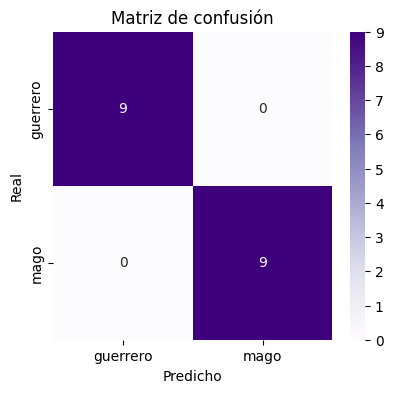

In [4]:
matriz = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Purples",
    xticklabels=pipeline.classes_, yticklabels=pipeline.classes_, ax=ax,
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión")
plt.show()


---
## 5. La frontera de decisión: cómo "piensa" el modelo

Hasta ahora vimos cómo clasifica el modelo los puntos que ya teníamos. La **frontera de decisión** va más allá: pinta **todo el plano** fuerza/velocidad según qué clase predeciría el modelo en cada zona, aunque ahí no haya ningún personaje real.

Para dibujarla, generamos una grilla fina de puntos que cubre todo el gráfico, le pedimos al modelo que clasifique cada uno, y coloreamos según la predicción.


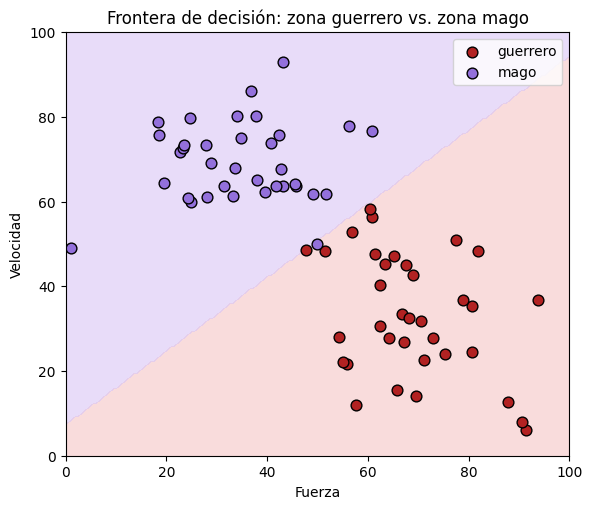

In [5]:
# Grilla de puntos que cubre todo el plano fuerza/velocidad
fuerza_grilla = np.linspace(0, 100, 200)
velocidad_grilla = np.linspace(0, 100, 200)
fuerza_malla, velocidad_malla = np.meshgrid(fuerza_grilla, velocidad_grilla)

puntos_grilla = pd.DataFrame({
    "fuerza": fuerza_malla.ravel(),
    "velocidad": velocidad_malla.ravel(),
})

# El modelo predice una clase para cada punto de la grilla
predicciones_grilla = pipeline.predict(puntos_grilla)
predicciones_numericas = (predicciones_grilla == "mago").astype(int).reshape(fuerza_malla.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.contourf(
    fuerza_malla, velocidad_malla, predicciones_numericas,
    levels=[-0.5, 0.5, 1.5], colors=["#f6c6c6", "#d9c6f6"], alpha=0.6,
)

for clase, grupo in personajes.groupby("clase"):
    ax.scatter(grupo["fuerza"], grupo["velocidad"], label=clase, color=colores[clase], edgecolor="black", s=60)

ax.set_xlabel("Fuerza")
ax.set_ylabel("Velocidad")
ax.set_title("Frontera de decisión: zona guerrero vs. zona mago")
ax.legend()
plt.show()


---
## 📝 Actividad final — Creá tu propio personaje

**Consigna:**
- Elegí `fuerza` y `velocidad` para un personaje inventado por vos.
- Predecí su clase con el `pipeline`.
- Volvé a dibujar la frontera de decisión de la sección 5, agregando tu personaje como una estrella.


Tu personaje fue clasificado como: mago


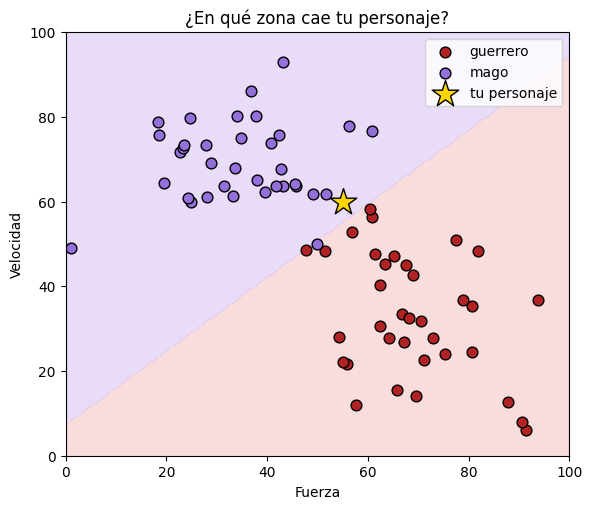

In [6]:
# ACTIVIDAD FINAL: crear tu propio personaje
# TODO: elegir fuerza y velocidad para tu personaje
mi_personaje = pd.DataFrame({"fuerza": [55], "velocidad": [60]})

# TODO: predecir su clase
prediccion = pipeline.predict(mi_personaje)[0]
print("Tu personaje fue clasificado como:", prediccion)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.contourf(
    fuerza_malla, velocidad_malla, predicciones_numericas,
    levels=[-0.5, 0.5, 1.5], colors=["#f6c6c6", "#d9c6f6"], alpha=0.6,
)

for clase, grupo in personajes.groupby("clase"):
    ax.scatter(grupo["fuerza"], grupo["velocidad"], label=clase, color=colores[clase], edgecolor="black", s=60)

ax.scatter(
    mi_personaje["fuerza"], mi_personaje["velocidad"],
    marker="*", s=400, color="gold", edgecolor="black", label="tu personaje",
)
ax.set_xlabel("Fuerza")
ax.set_ylabel("Velocidad")
ax.set_title("¿En qué zona cae tu personaje?")
ax.legend()
plt.show()


---
## ✅ Resumen y cierre del módulo

| Herramienta | Qué resuelve |
|---|---|
| `pd.concat(...)`, `.clip(...)` | Armar un dataset de juguete con pandas |
| `Pipeline([("escalar", ...), ("modelo", ...)])` | Encadenar preprocesamiento + modelo |
| `sns.heatmap(confusion_matrix(...))` | Ver los errores del modelo como gráfico |
| `np.meshgrid(...)` + `ax.contourf(...)` | Dibujar la frontera de decisión de un modelo |
| `pipeline.predict(...)` | Clasificar un personaje inventado por vos |

**Lo que construiste en este proyecto:**
- un dataset propio de principio a fin, con pandas,
- un modelo entrenado y evaluado con gráficos,
- una visualización de cómo "piensa" el modelo en todo el plano, no solo en tus datos.

**Cierre del Módulo 3:** empezamos con Python puro (Clases 1-8), sumamos NumPy y pandas (Clases 9-11) y terminamos entrenando y visualizando modelos de clasificación con datos propios (Clases 12-14).

**Lo que viene — Módulo 4:** pasamos de modelos que predicen una categoría a modelos de lenguaje (LLMs) que generan texto. La Clase 1 de Módulo 4 te muestra cómo correr tu primer LLM 100% local con `llama.cpp`.
